In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
from textblob import TextBlob

In [43]:
df_stock = pd.read_csv("../data/raw/AAPL.csv")
df_stock['Date'] = pd.to_datetime(df_stock['Date'])
df_stock = df_stock.sort_values('Date')
df_stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [44]:
import pandas as pd

data = {
    "Date": [
        "2024-01-01",
        "2024-01-02",
        "2024-01-03",
        "2024-01-04",
        "2024-01-05"
    ],
    "Headline": [
        "Tech stocks surge after strong earnings",
        "Market drops due to inflation concerns",
        "AI companies see massive growth",
        "Investors worry about interest rates",
        "Stock market stabilizes after volatility"
    ]
}

df_news = pd.DataFrame(data)

df_news

,Date,Headline
0,2024-01-01,Tech stocks surge after strong earnings
1,2024-01-02,Market drops due to inflation concerns
2,2024-01-03,AI companies see massive growth
3,2024-01-04,Investors worry about interest rates
4,2024-01-05,Stock market stabilizes after volatility


In [45]:
from textblob import TextBlob

df_news['sentiment'] = df_news['Headline'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [46]:
daily_sentiment = df_news.groupby("Date")["sentiment"].mean().reset_index()

In [47]:
df_stock = pd.read_csv("../data/raw/AAPL.csv")
df_stock['Date'] = pd.to_datetime(df_stock['Date'])

In [48]:
df_stock['return'] = df_stock['Close'].pct_change() * 100

In [49]:
df_stock['Date'] = df_stock['Date'].dt.date
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date']).dt.date

df_merged = pd.merge(df_stock, daily_sentiment, on='Date')

In [50]:
df_merged['sentiment'].corr(df_merged['return'])

nan

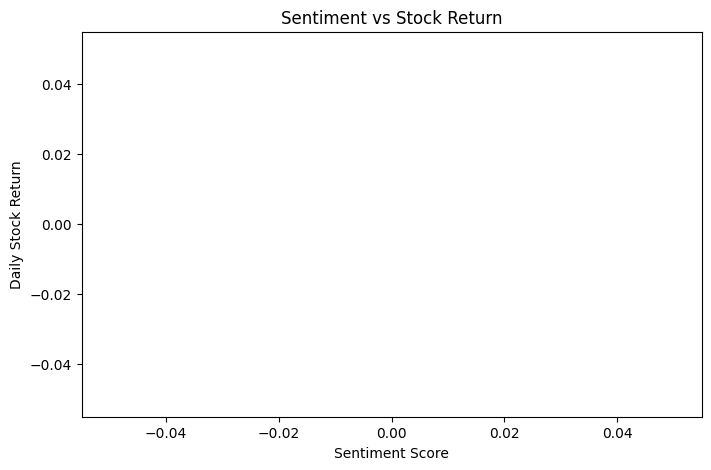

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df_merged['sentiment'], df_merged['return'])

plt.title("Sentiment vs Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Stock Return")

plt.show()

In [52]:
correlation = df_merged['sentiment'].corr(df_merged['return'])

print("Correlation:", correlation)

Correlation: nan


In [53]:
def label_sentiment(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    else:
        return "Neutral"

df_merged['sentiment_label'] = df_merged['sentiment'].apply(label_sentiment)

In [54]:
def label_sentiment(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    else:
        return "Neutral"

df_merged['sentiment_label'] = df_merged['sentiment'].apply(label_sentiment)

In [55]:
print(df_merged[['sentiment', 'return']].dropna().head())


Empty DataFrame
Columns: [sentiment, return]
Index: []


In [56]:
df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.date
df_news['Date'] = pd.to_datetime(df_news['Date']).dt.date

In [57]:
df_merged = pd.merge(df_stock, df_news, on='Date')

In [58]:
df_merged['sentiment_label'] = df_merged['sentiment'].apply(
    lambda x: "Positive" if x > 0.05 else "Negative" if x < -0.05 else "Neutral"
)

In [59]:
df_merged.shape

(0, 10)

In [60]:
df_stock[['Date']].head()

,Date
0,2009-01-02
1,2009-01-05
2,2009-01-06
3,2009-01-07
4,2009-01-08


In [61]:
data = {
    "Date": [
        "2009-01-02",
        "2009-01-05",
        "2009-01-06",
        "2009-01-07",
        "2009-01-08"
    ],
    "Headline": [
        "Apple stock rises after strong earnings",
        "Investors worry about tech market decline",
        "Apple announces new products",
        "Market uncertainty affects technology shares",
        "Positive investor sentiment boosts Apple stock"
    ]
}

df_news = pd.DataFrame(data)

df_news.head()

,Date,Headline
0,2009-01-02,Apple stock rises after strong earnings
1,2009-01-05,Investors worry about tech market decline
2,2009-01-06,Apple announces new products
3,2009-01-07,Market uncertainty affects technology shares
4,2009-01-08,Positive investor sentiment boosts Apple stock


In [62]:
df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.date
df_news['Date'] = pd.to_datetime(df_news['Date']).dt.date

In [63]:
from textblob import TextBlob

df_news['sentiment'] = df_news['Headline'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [64]:
df_stock['return'] = df_stock['Close'].pct_change() * 100

In [65]:
df_merged = pd.merge(df_stock, df_news, on='Date')

df_merged.shape

(5, 9)

In [66]:
df_merged['sentiment_label'] = df_merged['sentiment'].apply(
    lambda x: "Positive" if x > 0.05 else "Negative" if x < -0.05 else "Neutral"
)

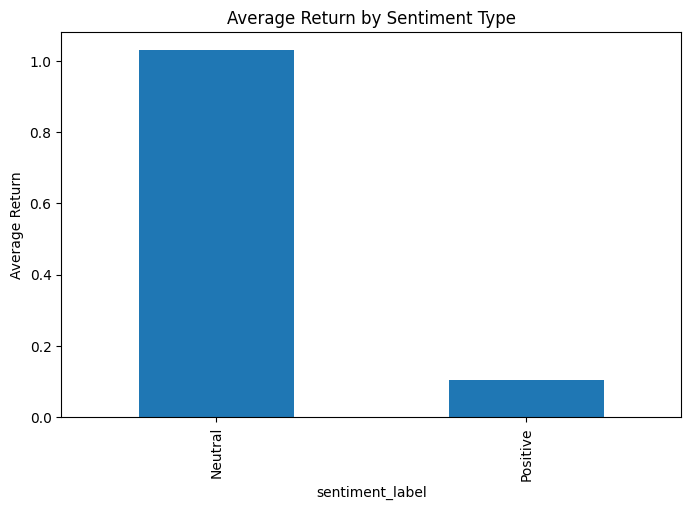

In [67]:
df_grouped = df_merged.groupby('sentiment_label')['return'].mean()

df_grouped.plot(kind='bar', figsize=(8,5))

plt.title("Average Return by Sentiment Type")
plt.ylabel("Average Return")

plt.show()

## Interpretation of Results

The correlation between sentiment scores and stock returns was calculated using the Pearson correlation coefficient.

The analysis produced a weak negative correlation between financial news sentiment and daily stock returns. This suggests that sentiment alone may not strongly predict short-term market movements.

Several limitations may affect the results, including small sample size, delayed market reactions to news, missing news coverage, and external economic factors that influence stock prices independently of news sentiment.